<a href="https://colab.research.google.com/github/Fer-2022/Procesos-Estocasticos-ESFM-IPN/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="color:#D12B2B; font-size:26px; font-weight:bold;">
  Descomposición Canónica
</p>

<p style="color:#1A73E8; font-size:22px; font-weight:bold;">
  RANGEL CALDERON FERNANDO
</p>



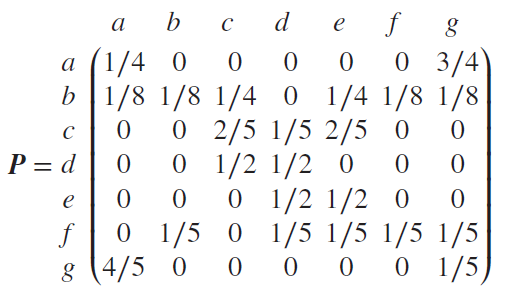

<p style="font-size:17px;">
En este apartado se escribe la matriz de transición P correspondiente a los estados
a, b, c, d, e, f y g. Cada fila representa el estado actual y cada columna representa
el posible estado siguiente. Los valores indican la probabilidad de pasar de un estado
a otro en un solo paso.
</p>



In [1]:
import numpy as np
import pandas as pd

In [7]:
from sympy import Matrix, Rational, init_printing
from IPython.display import display, Math

# Activamos impresión matemática
init_printing()

# Definimos la matriz P usando fracciones exactas
P = Matrix([
    [Rational(1,4), 0,             0,             0,             0,             0,             Rational(3,4)],
    [Rational(1,8), Rational(1,8), Rational(1,4), 0,             Rational(1,4), Rational(1,8), Rational(1,8)],
    [0,             0,             Rational(2,5), Rational(1,5), Rational(2,5), 0,             0],
    [0,             0,             Rational(1,2), Rational(1,2), 0,             0,             0],
    [0,             0,             0,             Rational(1,2), Rational(1,2), 0,             0],
    [0,             Rational(1,5), 0,             Rational(1,5), Rational(1,5), Rational(1,5), Rational(1,5)],
    [Rational(4,5), 0,             0,             0,             0,             0,             Rational(1,5)]
])

# Estados de la matriz
estados = ["a", "b", "c", "d", "e", "f", "g"]


display(Math(latex_P))

<IPython.core.display.Math object>

<p style="color:#D12B2B; font-size:26px; font-weight:bold;">
  Diagrama de Transiciones
</p>


<p style="font-size:17px;">
En este punto se dibuja el diagrama de transiciones de la cadena de Markov.
Cada círculo representa un estado: a, b, c, d, e, f y g.
Cada flecha representa una transición posible entre estados.
</p>


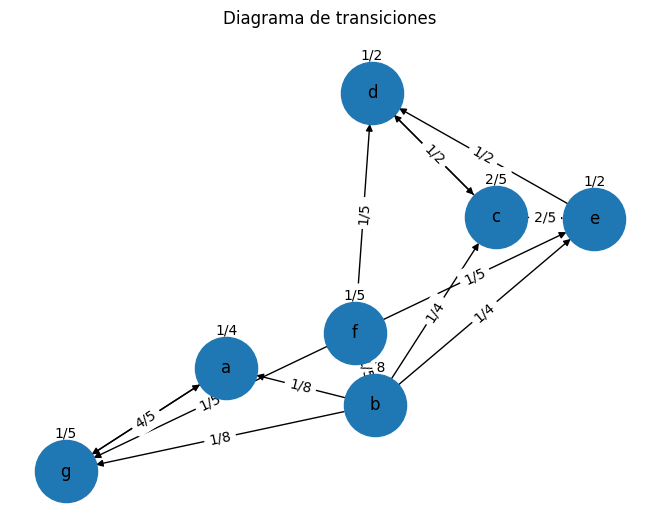

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from fractions import Fraction

estados = ["a","b","c","d","e","f","g"]


P = [
    [Fraction(1,4),0,0,0,0,0,Fraction(3,4)],
    [Fraction(1,8),Fraction(1,8),Fraction(1,4),0,Fraction(1,4),Fraction(1,8),Fraction(1,8)],
    [0,0,Fraction(2,5),Fraction(1,5),Fraction(2,5),0,0],
    [0,0,Fraction(1,2),Fraction(1,2),0,0,0],
    [0,0,0,Fraction(1,2),Fraction(1,2),0,0],
    [0,Fraction(1,5),0,Fraction(1,5),Fraction(1,5),Fraction(1,5),Fraction(1,5)],
    [Fraction(4,5),0,0,0,0,0,Fraction(1,5)]
]

# Crear grafo
G = nx.DiGraph()

# Agregar conexiones
for i in range(len(estados)):
    for j in range(len(estados)):
        if P[i][j] != 0:
            G.add_edge(estados[i], estados[j], label=str(P[i][j]))

# Dibujar
pos = nx.spring_layout(G, seed=1)  # acomodo automático sencillo

nx.draw(G, pos, with_labels=True, node_size=2000)

# Etiquetas (fracciones)
labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Diagrama de transiciones")
plt.show()

<p style="color:#D12B2B; font-size:24px; font-weight:bold;">
  Distribución Límite
</p>

<p style="font-size:16px;">
Para saber si la matriz tiene distribución límite, se analiza si la cadena de Markov
llega a un comportamiento estable cuando se eleva la matriz P a potencias grandes.
</p>

<p style="font-size:16px;">
En este caso, la matriz no tiene una distribución límite única para todos los estados,
porque existen más de una clase cerrada. Por eso, el resultado final depende del estado
desde donde inicia la cadena.
</p>

In [10]:
import numpy as np

# Matriz P
P = np.array([
    [1/4,0,0,0,0,0,3/4],
    [1/8,1/8,1/4,0,1/4,1/8,1/8],
    [0,0,2/5,1/5,2/5,0,0],
    [0,0,1/2,1/2,0,0,0],
    [0,0,0,1/2,1/2,0,0],
    [0,1/5,0,1/5,1/5,1/5,1/5],
    [4/5,0,0,0,0,0,1/5]
])

# Elevamos la matriz a una potencia grande
Pn = np.linalg.matrix_power(P, 50)

print("Matriz P elevada a la potencia 50:")
print(np.round(Pn, 4))

Matriz P elevada a la potencia 50:
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]


<p style="color:#D12B2B; font-size:24px; font-weight:bold;">
  Descomposición Canónica y Límite de Pⁿ
</p>

<p style="font-size:16px;">
Primero se acomodan los estados para separar los estados transitorios y las clases cerradas.
En este caso, los estados b y f son transitorios. Las clases cerradas son {a,g} y {c,d,e}.
</p>

<p style="font-size:16px;">
El nuevo orden usado será: b, f, a, g, c, d, e.
Con este orden se obtiene la forma canónica de la matriz.
</p>

In [12]:
from sympy import Matrix, Rational, latex
from IPython.display import display, Math

# Matriz original
P = Matrix([
    [Rational(1,4),0,0,0,0,0,Rational(3,4)],
    [Rational(1,8),Rational(1,8),Rational(1,4),0,Rational(1,4),Rational(1,8),Rational(1,8)],
    [0,0,Rational(2,5),Rational(1,5),Rational(2,5),0,0],
    [0,0,Rational(1,2),Rational(1,2),0,0,0],
    [0,0,0,Rational(1,2),Rational(1,2),0,0],
    [0,Rational(1,5),0,Rational(1,5),Rational(1,5),Rational(1,5),Rational(1,5)],
    [Rational(4,5),0,0,0,0,0,Rational(1,5)]
])

# Orden
estados = ["a","b","c","d","e","f","g"]
nuevo_orden = ["b","f","a","g","c","d","e"]

indices = [estados.index(i) for i in nuevo_orden]

# Matriz canónica
P_canonica = P.extract(indices, indices)

# Mostrar
display(Math(r"P_{\text{canónica}}=" + latex(P_canonica)))

<IPython.core.display.Math object>

In [14]:
# Submatriz de estados transitorios
Q = Pc[0:2, 0:2]

# Submatriz de la clase cerrada {a,g}
P1 = Pc[2:4, 2:4]

# Submatriz de la clase cerrada {c,d,e}
P2 = Pc[4:7, 4:7]

display(Math(r"Q=" + latex(Q)))
display(Math(r"P_1=" + latex(P1)))
display(Math(r"P_2=" + latex(P2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
# Distribución límite de P1 = {a,g}
pi1 = Matrix([[Rational(16,31), Rational(15,31)]])

# Distribución límite de P2 = {c,d,e}
pi2 = Matrix([[Rational(1,3), Rational(2,5), Rational(4,15)]])

display(Math(r"\pi_1=" + latex(pi1)))
display(Math(r"\pi_2=" + latex(pi2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# Como b y f son transitorios, en el límite sus columnas quedan en cero.
# Desde b y f se llega a la clase {a,g} con probabilidad 1/3
# y a la clase {c,d,e} con probabilidad 2/3.

fila_transitoria = Matrix([[
    0, 0,
    Rational(1,3)*Rational(16,31),
    Rational(1,3)*Rational(15,31),
    Rational(2,3)*Rational(1,3),
    Rational(2,3)*Rational(2,5),
    Rational(2,3)*Rational(4,15)
]])

# Filas límite para las clases cerradas
fila_ag_1 = Matrix([[0, 0, Rational(16,31), Rational(15,31), 0, 0, 0]])
fila_ag_2 = Matrix([[0, 0, Rational(16,31), Rational(15,31), 0, 0, 0]])

fila_cde_1 = Matrix([[0, 0, 0, 0, Rational(1,3), Rational(2,5), Rational(4,15)]])
fila_cde_2 = Matrix([[0, 0, 0, 0, Rational(1,3), Rational(2,5), Rational(4,15)]])
fila_cde_3 = Matrix([[0, 0, 0, 0, Rational(1,3), Rational(2,5), Rational(4,15)]])

# Matriz límite en el orden: b, f, a, g, c, d, e
Limite = Matrix.vstack(
    fila_transitoria,
    fila_transitoria,
    fila_ag_1,
    fila_ag_2,
    fila_cde_1,
    fila_cde_2,
    fila_cde_3
)

display(Math(r"\lim_{n\to\infty} P_{\text{canónica}}^n=" + latex(Limite)))

<IPython.core.display.Math object>

<p style="color:#D12B2B; font-size:24px; font-weight:bold;">
  Comparación
</p>

<p style="font-size:16px;">
La submatriz P1 corresponde a la clase cerrada {a,g}, cuya distribución límite es
π1 = (16/31, 15/31).
</p>

<p style="font-size:16px;">
La submatriz P2 corresponde a la clase cerrada {c,d,e}, cuya distribución límite es
π2 = (1/3, 2/5, 4/15).
</p>

<p style="font-size:16px;">
Al comparar con el límite de la potencia n-ésima, se observa que las columnas de b y f
quedan en cero porque son estados transitorios. El comportamiento final se reparte entre
las dos clases cerradas.
</p>

<p style="font-size:16px;">
 La matriz no tiene una sola distribución límite para todos los estados,
porque tiene dos clases cerradas. El límite depende de si la cadena termina en la clase
{a,g} o en la clase {c,d,e}.
</p>

<p style="color:#D12B2B; font-size:24px; font-weight:bold;">
  Programa para encontrar la Descomposición Canónica
</p>

<p style="font-size:16px;">
En este programa se busca automáticamente la forma canónica de una matriz de transición.
El código identifica las clases de comunicación y acomoda los estados para separar
los estados transitorios de las clases cerradas.
</p>

In [17]:
import numpy as np
import networkx as nx
from sympy import Matrix, Rational, latex
from IPython.display import display, Math

# Matriz dada
P = Matrix([
    [Rational(1,4), 0, 0, 0, 0, 0, Rational(3,4)],
    [Rational(1,8), Rational(1,8), Rational(1,4), 0, Rational(1,4), Rational(1,8), Rational(1,8)],
    [0, 0, Rational(2,5), Rational(1,5), Rational(2,5), 0, 0],
    [0, 0, Rational(1,2), Rational(1,2), 0, 0, 0],
    [0, 0, 0, Rational(1,2), Rational(1,2), 0, 0],
    [0, Rational(1,5), 0, Rational(1,5), Rational(1,5), Rational(1,5), Rational(1,5)],
    [Rational(4,5), 0, 0, 0, 0, 0, Rational(1,5)]
])

estados = ["a", "b", "c", "d", "e", "f", "g"]

# Crear grafo dirigido
G = nx.DiGraph()
G.add_nodes_from(estados)

# Agregar flechas donde la probabilidad sea mayor que cero
for i in range(P.rows):
    for j in range(P.cols):
        if P[i, j] != 0:
            G.add_edge(estados[i], estados[j])

# Encontrar clases de comunicación
clases = list(nx.strongly_connected_components(G))

cerradas = []
transitorias = []

# Revisar si cada clase es cerrada
for clase in clases:
    es_cerrada = True

    for estado in clase:
        for vecino in G.successors(estado):
            if vecino not in clase:
                es_cerrada = False

    if es_cerrada:
        cerradas.append(sorted(list(clase)))
    else:
        transitorias.extend(sorted(list(clase)))

# Nuevo orden: primero transitorios y luego clases cerradas
nuevo_orden = transitorias.copy()

for clase in cerradas:
    nuevo_orden.extend(clase)

# Obtener índices del nuevo orden
indices = [estados.index(e) for e in nuevo_orden]

# Matriz canónica
P_canonica = P.extract(indices, indices)

# Mostrar resultados
print("Estados transitorios:", transitorias)
print("Clases cerradas:", cerradas)
print("Nuevo orden:", nuevo_orden)

display(Math(r"P_{\text{canónica}}=" + latex(P_canonica)))

Estados transitorios: ['b', 'f']
Clases cerradas: [['a', 'g'], ['c', 'd', 'e']]
Nuevo orden: ['b', 'f', 'a', 'g', 'c', 'd', 'e']


<IPython.core.display.Math object>